In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

In [3]:
import pandas as pd

df = pd.read_csv("/content/delhi_metro_updated.csv")



In [4]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,NaN,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak


In [5]:
df.drop(columns = ['TripID','Distance_km','Fare','Cost_per_passenger','Ticket_Type','Remarks'], inplace =
        True)

In [6]:
df = df.dropna()

In [7]:
df.shape

(132834, 4)

In [8]:
df.head()

,Date,From_Station,To_Station,Passengers
0,2022-05-08,Inderlok,Kashmere Gate,13.0
1,2023-01-12,Model Town,Dilshad Garden,15.0
2,2023-07-13,Kashmere Gate,Netaji Subhash Place,9.0
3,2022-11-10,Chandni Chowk,Hauz Khas,27.0
4,2022-11-06,Rajiv Chowk,Kalkaji Mandir,23.0


In [9]:
df['From_Station'] = df['From_Station'].str.lower().str.strip()
df['To_Station'] = df['To_Station'].str.lower().str.strip()

In [10]:
entries = df.groupby(['Date', 'From_Station'])['Passengers'].sum().reset_index()
entries.columns = ['date', 'station', 'entries']

In [11]:
exits = df.groupby(['Date', 'To_Station'])['Passengers'].sum().reset_index()
exits.columns = ['date', 'station', 'exits']

In [12]:
station_df = pd.merge(entries, exits, on=['date', 'station'], how='outer')
station_df = station_df.fillna(0)

In [13]:
station_df['total_demand'] = station_df['entries'] + station_df['exits']

In [14]:
station_df = station_df.drop(['entries', 'exits'], axis=1)

In [15]:
station_df['day_of_week'] = station_df['date'].dt.dayofweek
station_df['day_of_month'] = station_df['date'].dt.day
station_df['month'] = station_df['date'].dt.month

station_df['is_weekend'] = station_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [31]:
station_df['prev_2_day_demand'] = station_df.groupby('station')['total_demand'].shift(2)
station_df['prev_7_day_demand'] = station_df.groupby('station')['total_demand'].shift(7)  # same day last week
station_df['rolling_avg_7'] = station_df.groupby('station')['total_demand'].rolling(7).mean().reset_index(0, drop=True)
station_df['rolling_std_3'] = station_df.groupby('station')['total_demand'].rolling(3).std().reset_index(0, drop=True)

In [32]:
station_df['is_monday'] = (station_df['day_of_week'] == 0).astype(int)
station_df['is_friday'] = (station_df['day_of_week'] == 4).astype(int)
station_df['week_of_year'] = station_df['date'].dt.isocalendar().week.astype(int)

In [33]:
station_df['crowd_level'] = pd.qcut(
    station_df['total_demand'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

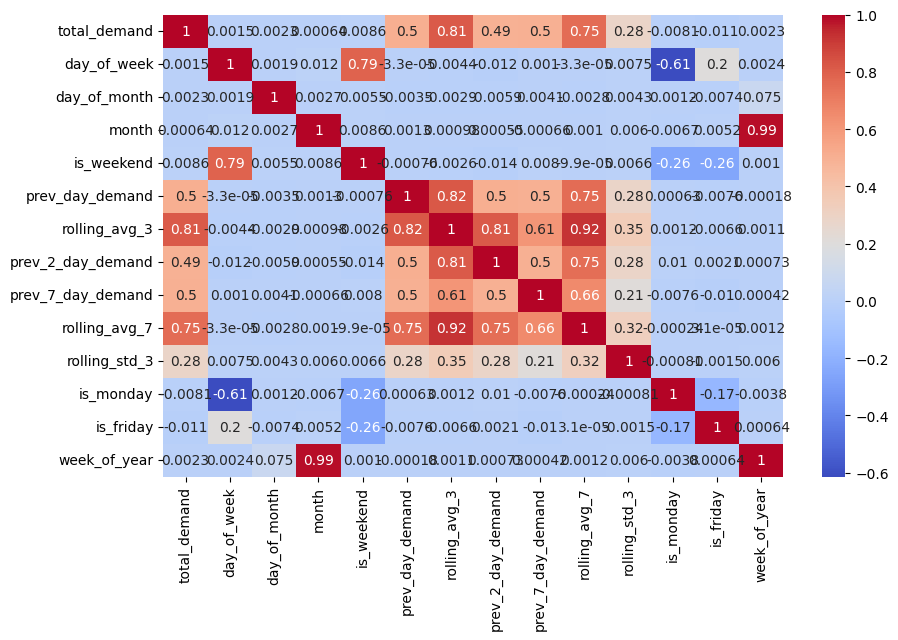

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = station_df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [35]:
station_df = station_df.sort_values(by='date')

In [36]:
y = station_df['crowd_level']

In [37]:
X = station_df.drop(['crowd_level', 'total_demand', 'date'], axis=1)

In [38]:
station_df = station_df.sort_values(by=['station', 'date'])

station_df['prev_day_demand'] = station_df.groupby('station')['total_demand'].shift(1)

In [39]:
station_df['rolling_avg_3'] = station_df.groupby('station')['total_demand'].rolling(3).mean().reset_index(0, drop=True)

In [40]:
station_df = station_df.dropna()

In [41]:
y = station_df['crowd_level']

X = station_df.drop(['crowd_level', 'total_demand', 'date'], axis=1)

In [42]:
X = pd.get_dummies(X, columns=['station'], drop_first=True)

In [43]:
train_size = int(0.8 * len(X))

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit only on train, transform both

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [49]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [50]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [55]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1)
xgb.fit(X_train, y_train_enc)
y_pred_xgb = le.inverse_transform(xgb.predict(X_test))

In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")


Logistic Regression
Accuracy: 0.8064082885648504
              precision    recall  f1-score   support

        High       0.86      0.93      0.90      1551
         Low       0.97      0.73      0.83      2356
      Medium       0.59      0.79      0.68      1305

    accuracy                           0.81      5212
   macro avg       0.81      0.82      0.80      5212
weighted avg       0.84      0.81      0.81      5212

[[1448   10   93]
 [   2 1719  635]
 [ 226   43 1036]]

Decision Tree
Accuracy: 0.9211435149654643
              precision    recall  f1-score   support

        High       0.96      0.95      0.96      1551
         Low       0.94      0.95      0.94      2356
      Medium       0.85      0.84      0.84      1305

    accuracy                           0.92      5212
   macro avg       0.91      0.91      0.91      5212
weighted avg       0.92      0.92      0.92      5212

[[1479    0   72]
 [   0 2231  125]
 [  60  154 1091]]

Random Forest
Accuracy: 0.9165387